## Parte 1 Preprocesamiento y Codificación
Objetivo: Limpiar definitivamente los datos detectados en el EDA y convertir todo a números para que el algoritmo pueda leerlos.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ===========================================================
# FASE 3 - PREPROCESAMIENTO DE DATOS
# Objetivo:
# Preparar el dataset para técnicas de reducción de dimensionalidad,
# asegurando calidad, consistencia y homogeneidad en las variables.
# ===========================================================

# -----------------------------------------------------------
# 1. CARGA Y PREPARACIÓN INICIAL
# -----------------------------------------------------------

# Se carga el dataset original. El separador es tabulación (\t)
df = pd.read_csv('../data/marketing_campaign.csv', sep='\t')

# A partir del año de nacimiento se construye la variable "Age",
# la cual resulta más interpretable y útil para el análisis.
df['Age'] = 2024 - df['Year_Birth']

# Antes de aplicar cualquier filtro, se gestionan los valores faltantes.
# En este caso, la variable Income presenta algunos nulos (~1%),
# por lo que se imputan utilizando la mediana para evitar sesgos
# producidos por valores extremos.
df['Income'] = df['Income'].fillna(df['Income'].median())

# -----------------------------------------------------------
# 2. LIMPIEZA DE DATOS (SEGÚN HALLAZGOS DEL EDA)
# -----------------------------------------------------------

# Se eliminan registros con edades no realistas (mayores a 100 años),
# identificados previamente como errores de captura.
df = df[df['Age'] < 100]

# Se filtran ingresos extremadamente altos (outliers).
# Estos valores pueden distorsionar técnicas sensibles a la escala,
# como PCA, afectando la interpretación de los componentes.
df = df[df['Income'] < 200000]

# Se eliminan variables que no aportan valor al modelado:
# - ID: identificador único sin relevancia analítica
# - Dt_Customer: variable temporal sin transformación
# - Year_Birth: reemplazada por la variable Age
df_prep = df.drop(['ID', 'Dt_Customer', 'Year_Birth'], axis=1)

# -----------------------------------------------------------
# 3. CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# -----------------------------------------------------------

# La variable Education se trata como ordinal,
# por lo que se utiliza Label Encoding para conservar su jerarquía.
le = LabelEncoder()
df_prep['Education'] = le.fit_transform(df_prep['Education'])

# La variable Marital_Status es de tipo nominal (sin orden inherente).
# Se aplica One-Hot Encoding para evitar introducir relaciones artificiales.
df_prep = pd.get_dummies(df_prep, columns=['Marital_Status'])

# -----------------------------------------------------------
# 4. ESCALADO DE VARIABLES
# -----------------------------------------------------------

# Se aplica estandarización (media = 0, desviación estándar = 1).
# Este paso es crítico para PCA, ya que evita que variables con
# mayor magnitud dominen el análisis.
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_prep)

# Se convierte nuevamente a DataFrame para facilitar su interpretación
# y asegurar compatibilidad con la siguiente fase (PCA).
df_scaled = pd.DataFrame(df_scaled, columns=df_prep.columns)

# -----------------------------------------------------------
# 5. VALIDACIÓN FINAL
# -----------------------------------------------------------

print("Preprocesamiento completado correctamente.")
print(f"Número de registros: {df_scaled.shape[0]}")
print(f"Número de variables: {df_scaled.shape[1]}")

Preprocesamiento completado correctamente.
Número de registros: 2236
Número de variables: 34


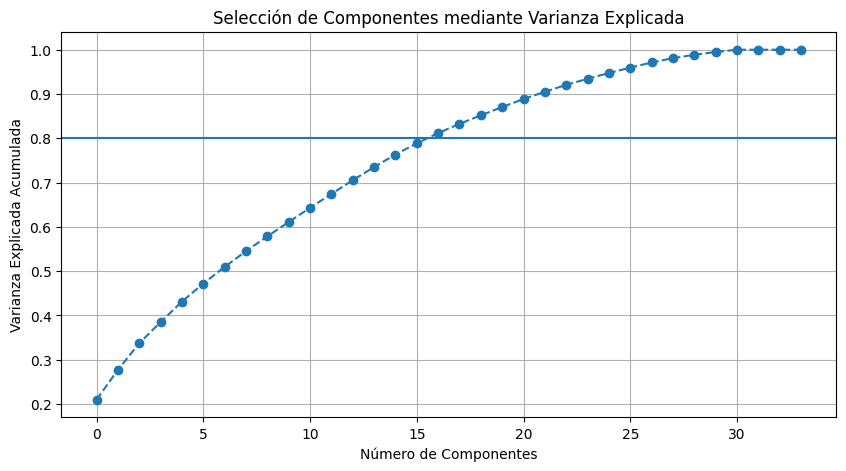

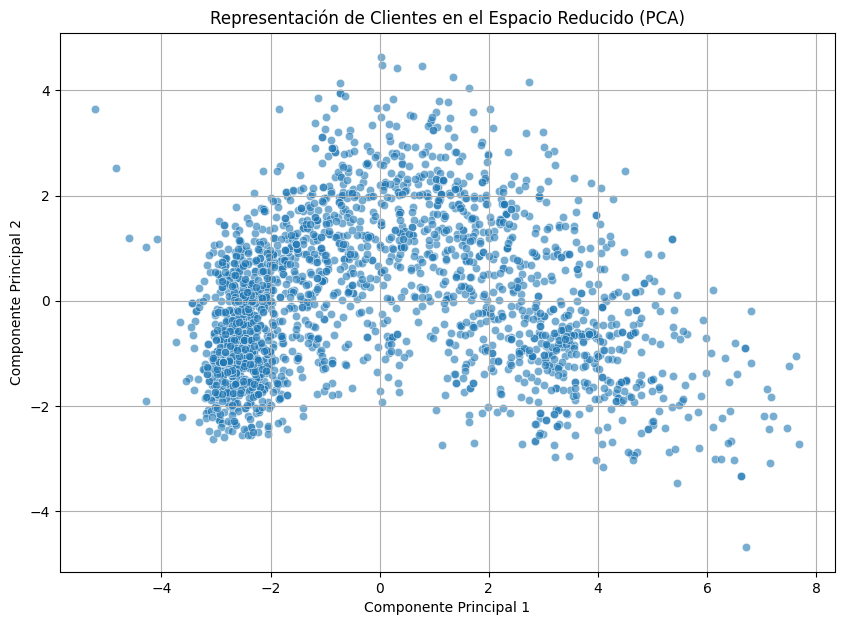

Varianza explicada por los 2 primeros componentes: 27.69%


In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ===========================================================
# FASE 3 - REDUCCIÓN DE DIMENSIONALIDAD (PCA)
# Objetivo:
# Reducir la cantidad de variables manteniendo la mayor cantidad
# de información posible, facilitando la interpretación de patrones.
# ===========================================================

# -----------------------------------------------------------
# 1. ANÁLISIS DE VARIANZA EXPLICADA
# -----------------------------------------------------------

# Se entrena un PCA sin restricción de componentes con el fin de
# evaluar cuánta varianza explica cada uno de ellos de forma acumulada.
pca_test = PCA()
pca_test.fit(df_scaled)

# Se calcula la varianza acumulada para analizar el punto de corte óptimo
varianza_acumulada = np.cumsum(pca_test.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(varianza_acumulada, marker='o', linestyle='--')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Selección de Componentes mediante Varianza Explicada')
plt.axhline(y=0.8, linestyle='-')  # Umbral común del 80%
plt.grid(True)
plt.show()

# En este punto se identifica visualmente cuántos componentes son necesarios
# para explicar al menos el 80% de la variabilidad del dataset.

# -----------------------------------------------------------
# 2. APLICACIÓN DE PCA
# -----------------------------------------------------------

# Para efectos de visualización, se reduce el dataset a 2 dimensiones.
# Esto permite observar la estructura general de los datos en un plano.
pca_final = PCA(n_components=2)
componentes_principales = pca_final.fit_transform(df_scaled)

# Se construye un DataFrame con los nuevos ejes transformados
df_pca = pd.DataFrame(
    data=componentes_principales,
    columns=['Componente Principal 1', 'Componente Principal 2']
)

# -----------------------------------------------------------
# 3. VISUALIZACIÓN DE RESULTADOS
# -----------------------------------------------------------

# Se genera un gráfico de dispersión para observar posibles agrupamientos
# o patrones en los clientes tras la reducción de dimensionalidad.
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Componente Principal 1',
    y='Componente Principal 2',
    data=df_pca,
    alpha=0.6
)

plt.title('Representación de Clientes en el Espacio Reducido (PCA)')
plt.grid(True)
plt.show()

# -----------------------------------------------------------
# 4. INTERPRETACIÓN GENERAL
# -----------------------------------------------------------

# Se calcula la proporción de varianza explicada por los dos primeros componentes.
varianza_total = pca_final.explained_variance_ratio_.sum()

print(f"Varianza explicada por los 2 primeros componentes: {varianza_total:.2%}")

# Este valor indica cuánta información del dataset original se conserva
# después de la reducción. Aunque 2 componentes no capturan toda la varianza,
# son suficientes para visualizar la estructura general del dataset.